**DETECCIÓN DE ANOMALIAS EN EL INVERSOR**
# 1. Cálculo del consumo medio por horas
# 2. ¿Cómo se distribuye el consumo a lo largo del día?
# 3. Gráfico de consumo medio diario
# 4. Boxplot de consumo medio diario

In [23]:
import pandas as pd
df_consumos = pd.read_csv('inverter_consumos_clean.csv')
df_consumos.head()

,date_time,date,time,weekday,generado,consumido,autoconsumo
0,2023-08-12 00:00 DST,2023-08-12,00:00,Saturday,0.0,0.453,0.0
1,2023-08-12 00:05 DST,2023-08-12,00:05,Saturday,0.0,0.456,0.0
2,2023-08-12 00:10 DST,2023-08-12,00:10,Saturday,0.0,0.480,0.0
3,2023-08-12 00:15 DST,2023-08-12,00:15,Saturday,0.0,0.509,0.0
4,2023-08-12 00:20 DST,2023-08-12,00:20,Saturday,0.0,0.485,0.0


In [24]:
df_consumos['year'] = pd.to_datetime(df_consumos['date']).dt.year
df_consumos['month'] = pd.to_datetime(df_consumos['date']).dt.month
df_consumos.head()

,date_time,date,time,weekday,generado,consumido,autoconsumo,year,month
0,2023-08-12 00:00 DST,2023-08-12,00:00,Saturday,0.0,0.453,0.0,2023,8
1,2023-08-12 00:05 DST,2023-08-12,00:05,Saturday,0.0,0.456,0.0,2023,8
2,2023-08-12 00:10 DST,2023-08-12,00:10,Saturday,0.0,0.480,0.0,2023,8
3,2023-08-12 00:15 DST,2023-08-12,00:15,Saturday,0.0,0.509,0.0,2023,8
4,2023-08-12 00:20 DST,2023-08-12,00:20,Saturday,0.0,0.485,0.0,2023,8


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df_consumos_medios_2023 = df_consumos.where(df_consumos['year'] == 2023).groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_2024 = df_consumos.where(df_consumos['year'] == 2024).groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_2025 = df_consumos.where(df_consumos['year'] == 2025).groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_2023.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_2024.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_2025.rename(columns={'consumido': 'consumos_mean'}, inplace=True)

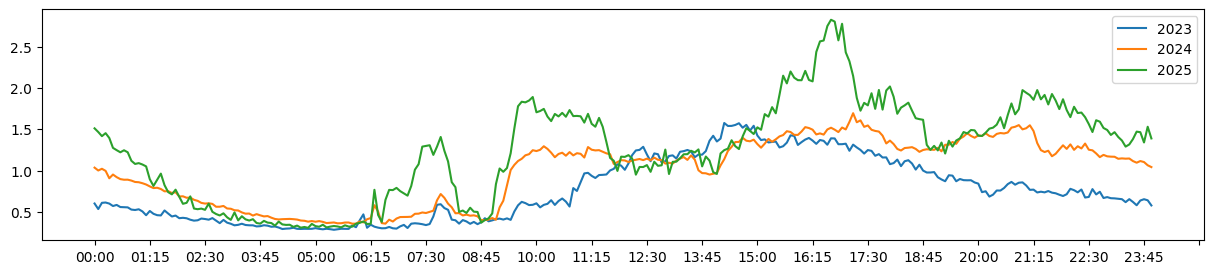

In [34]:
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df_consumos_medios_2023['time'], df_consumos_medios_2023['consumos_mean'], label='2023')
ax.plot(df_consumos_medios_2024['time'], df_consumos_medios_2024['consumos_mean'], label='2024')
ax.plot(df_consumos_medios_2025['time'], df_consumos_medios_2025['consumos_mean'], label='2025')
ax.xaxis.set_major_locator(plt.MaxNLocator(24))
plt.legend()
plt.show()

In [38]:
df_consumos_medios_L = df_consumos.where(df_consumos['weekday'] == 'Monday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_M = df_consumos.where(df_consumos['weekday'] == 'Tuesday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_X = df_consumos.where(df_consumos['weekday'] == 'Wednesday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_J = df_consumos.where(df_consumos['weekday'] == 'Thursday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_V = df_consumos.where(df_consumos['weekday'] == 'Friday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_S = df_consumos.where(df_consumos['weekday'] == 'Saturday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_D = df_consumos.where(df_consumos['weekday'] == 'Sunday').groupby('time')['consumido'].mean().reset_index()
df_consumos_medios_L.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_M.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_X.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_J.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_V.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_S.rename(columns={'consumido': 'consumos_mean'}, inplace=True)
df_consumos_medios_D.rename(columns={'consumido': 'consumos_mean'}, inplace=True)

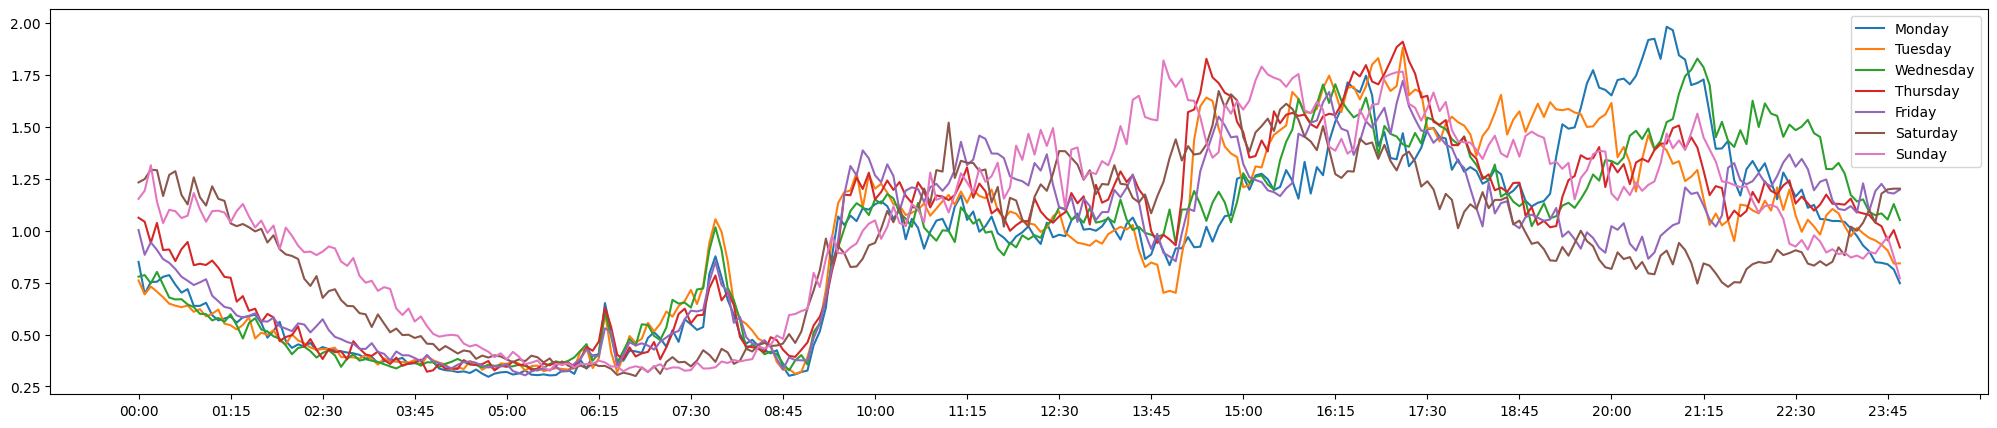

In [39]:
fig, ax = plt.subplots(figsize=(25,5))
ax.plot(df_consumos_medios_L['time'], df_consumos_medios_L['consumos_mean'], label='Monday')
ax.plot(df_consumos_medios_M['time'], df_consumos_medios_M['consumos_mean'], label='Tuesday')
ax.plot(df_consumos_medios_X['time'], df_consumos_medios_X['consumos_mean'], label='Wednesday')
ax.plot(df_consumos_medios_J['time'], df_consumos_medios_J['consumos_mean'], label='Thursday')
ax.plot(df_consumos_medios_V['time'], df_consumos_medios_V['consumos_mean'], label='Friday')
ax.plot(df_consumos_medios_S['time'], df_consumos_medios_S['consumos_mean'], label='Saturday')
ax.plot(df_consumos_medios_D['time'], df_consumos_medios_D['consumos_mean'], label='Sunday')
ax.xaxis.set_major_locator(plt.MaxNLocator(24))
plt.legend()
plt.show()